# HW 3: Logistic regression

In [1]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve,auc
from sklearn import metrics
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold

In [2]:
%pylab inline
%load_ext pycodestyle_magic

Populating the interactive namespace from numpy and matplotlib


## Import data

In [3]:
df = pd.read_csv('data/credit_scoring_train.csv')
df_test = pd.read_csv('data/credit_scoring_test.csv')

In [4]:
df.head()

,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
0,0,0.177772,50.5,11,0,3.0,2,0,5511.073207,0.898558,0
1,1,0.278636,65.3,9,2,2.0,0,0,4544.015711,0.010220,0
2,2,0.000000,55.4,0,0,0.0,0,0,NaN,1.005478,0
3,3,0.285555,53.4,12,2,1.0,0,0,13253.922692,1.309580,0
4,4,0.592800,56.5,10,6,0.0,0,0,12581.109054,0.045905,0


### Checking for na values

In [5]:
df.isnull().sum()

client_id                    0
DIR                          0
Age                          0
NumLoans                     0
NumRealEstateLoans           0
NumDependents             1527
Num30-59Delinquencies        0
Num60-89Delinquencies        0
Income                   11892
BalanceToCreditLimit         0
Delinquent90                 0
dtype: int64

### Plotting histogram for "Income"

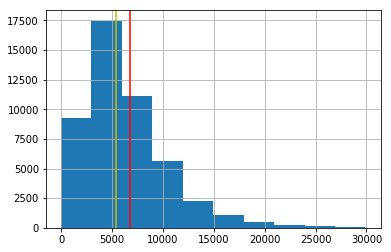

In [6]:
df.loc[df['Income'] < 30000, 'Income'].hist()
plt.axvline(df['Income'].mean(), c='r')
plt.axvline(df['Income'].median(), c='y')

### Seems logical to fill na with median ^

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

df_test['Income'] = df_test['Income'].fillna(df['Income'].median())

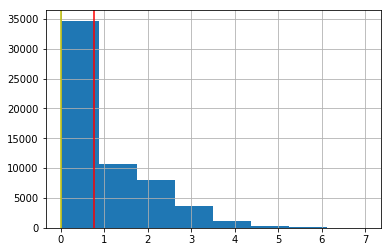

In [8]:
df.loc[df['NumDependents'] < 8,'NumDependents'].hist(bins=8)
plt.axvline(df['NumDependents'].mean(), c='r')
plt.axvline(df['NumDependents'].median(), c='y')

### Same for 'NumDependents' ^

In [9]:
df['NumDependents'] = df['NumDependents'].fillna(0)
df_test['NumDependents'] = df_test['NumDependents'].fillna(0)

In [10]:
df.isnull().sum()

client_id                0
DIR                      0
Age                      0
NumLoans                 0
NumRealEstateLoans       0
NumDependents            0
Num30-59Delinquencies    0
Num60-89Delinquencies    0
Income                   0
BalanceToCreditLimit     0
Delinquent90             0
dtype: int64

## Check for correlations

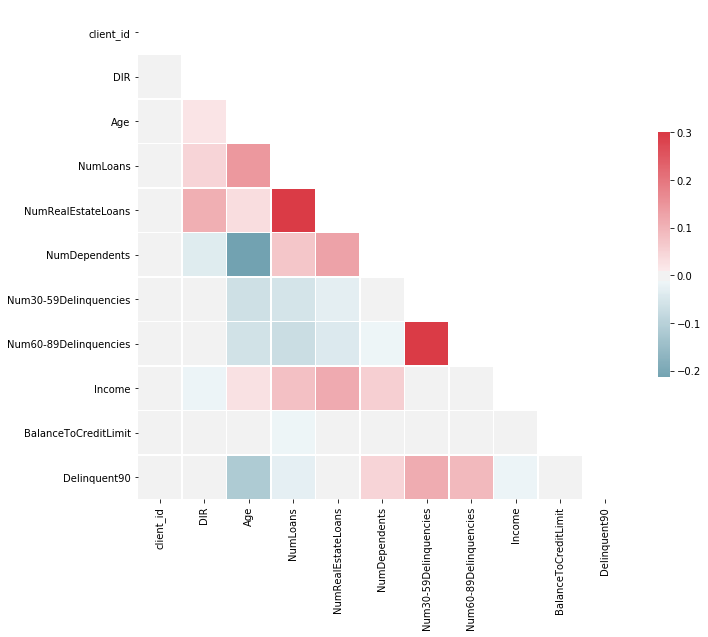

In [11]:
# Compute the correlation matrix
corr = df.corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0.,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### It seems that it's worth checking the 'Num30-59Delinquencies' vs 'Num60-89Delinquencies' columns, and 'NumLoans' vs 'NumRealEstateLoans' some time later

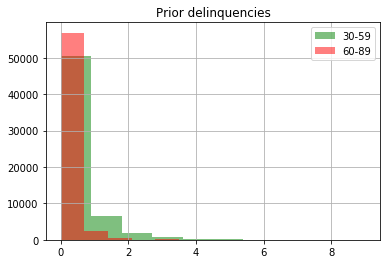

In [12]:
df.loc[df['Num30-59Delinquencies'] < 10,
       'Num30-59Delinquencies'].hist(alpha=0.5,
                                     color='g',
                                     label='30-59')
df.loc[df['Num60-89Delinquencies']<10,
       'Num60-89Delinquencies'].hist(alpha=0.5,
                                     color='r',
                                     label='60-89')
plt.legend()
plt.title('Prior delinquencies')
plt.show()

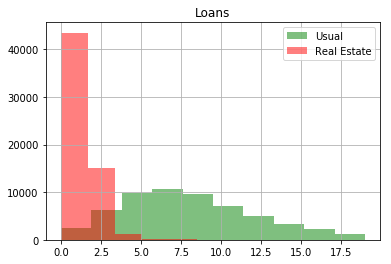

In [13]:
df.loc[df['NumLoans'] < 20,
       'NumLoans'].hist(alpha=0.5,
                        color='g',
                        label='Usual')
df.loc[df['NumRealEstateLoans'] < 20,
       'NumRealEstateLoans'].hist(alpha=0.5,
                                  color='r',
                                  label='Real Estate')
plt.legend()
plt.title('Loans')
plt.show()

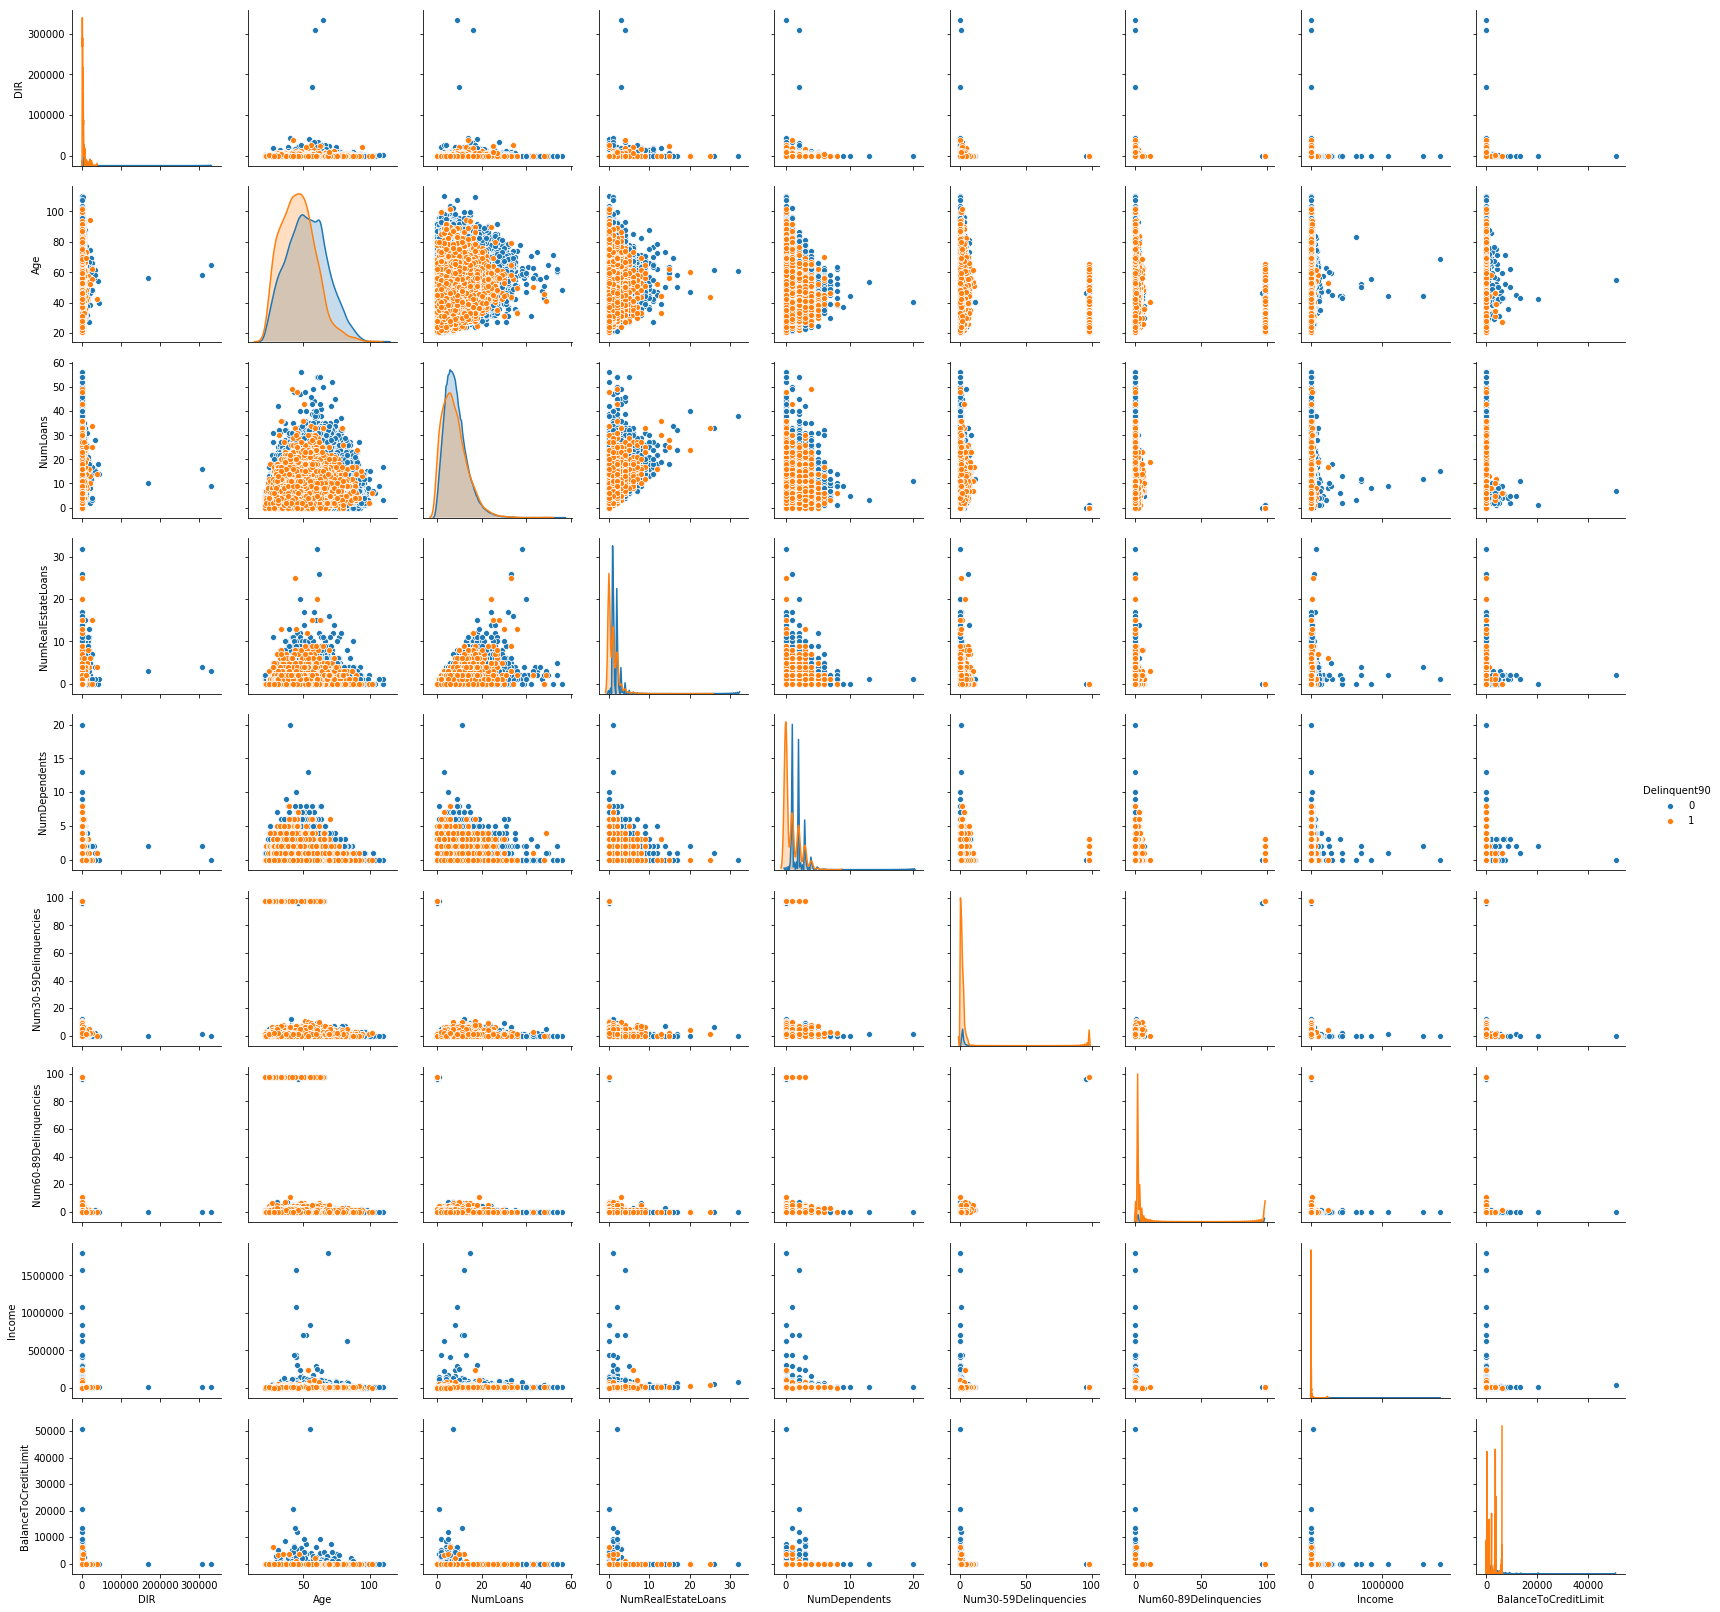

In [14]:
sns.pairplot(df, hue='Delinquent90', vars=['DIR', 'Age', 'NumLoans',
                                           'NumRealEstateLoans',
                                           'NumDependents',
                                           'Num30-59Delinquencies',
                                           'Num60-89Delinquencies',
                                           'Income', 'BalanceToCreditLimit'])

### Delinquency vs income

(0, 50000)

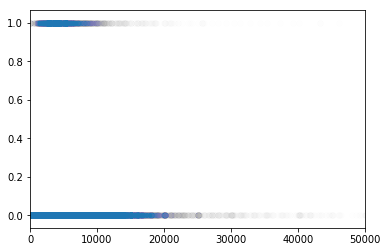

In [15]:
plt.scatter(df['Income'],df['Delinquent90'], alpha=0.002)
plt.xlim((0,50000))

### Delinquency vs age

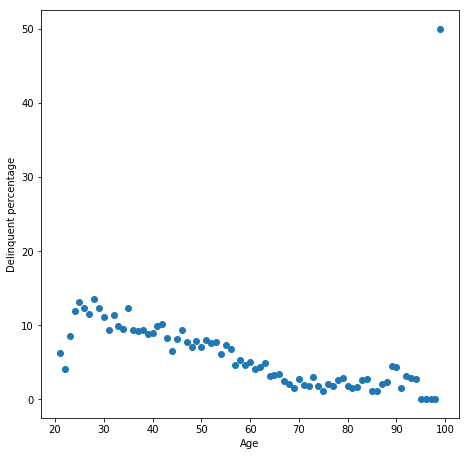

In [22]:
plt.figure(figsize=(7.5,7.5))
plt.scatter(np.arange(20, 100),
            [100*df.loc[np.round(df['Age']) == i,'Delinquent90'].sum()/
             df.loc[np.round(df['Age'])==i,'Delinquent90'].shape[0]
             for i in np.arange(20, 100)])
plt.xlabel('Age')
plt.ylabel('Delinquent percentage')
plt.show()

### balance_to_credit

In [23]:
df.loc[(df['Delinquent90'] == 1),'BalanceToCreditLimit'].describe()

count    3977.000000
mean        6.810689
std       156.082961
min         0.000000
25%         0.382680
50%         0.834542
75%         1.003706
max      6227.392870
Name: BalanceToCreditLimit, dtype: float64

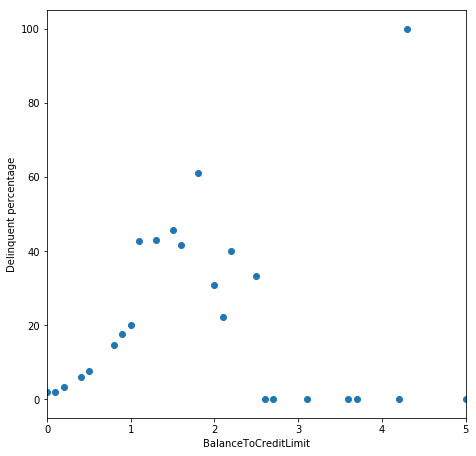

In [25]:
plt.figure(figsize=(7.5, 7.5))
plt.scatter(np.arange(0, 20, 0.1),
            [100*df.loc[np.round(df['BalanceToCreditLimit'], 1) == i, 'Delinquent90'].sum()/
             df.loc[np.round(df['BalanceToCreditLimit'],1) == i,'Delinquent90'].shape[0]
             for i in np.arange(0, 20, 0.1)])
plt.xlabel('BalanceToCreditLimit')
plt.ylabel('Delinquent percentage')
plt.xlim((0, 5))
plt.show()

### Binarizing some continuous features

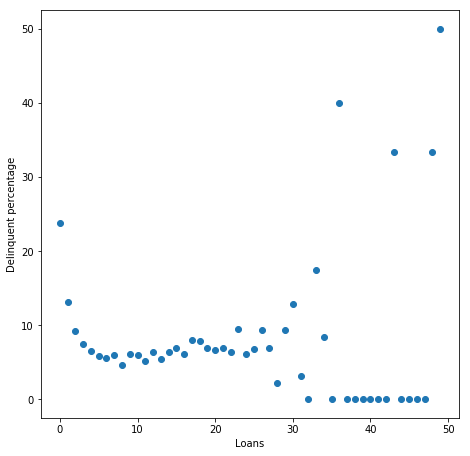

In [26]:
plt.figure(figsize=(7.5, 7.5))
plt.scatter(range(0, 50),
            [100*df.loc[df['NumLoans'] == i,'Delinquent90'].sum()/
             df.loc[df['NumLoans'] == i,'Delinquent90'].shape[0]
             for i in range(0, 50)])
plt.xlabel('Loans')
plt.ylabel('Delinquent percentage')
plt.show()

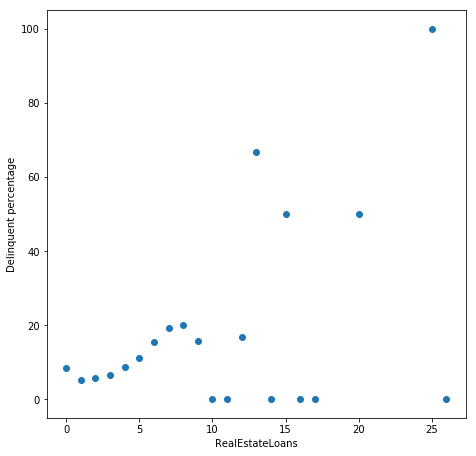

In [27]:
plt.figure(figsize=(7.5, 7.5))
plt.scatter(range(0, 30),
            [100*df.loc[df['NumRealEstateLoans'] == i,'Delinquent90'].sum()/
             df.loc[df['NumRealEstateLoans'] == i,'Delinquent90'].shape[0]
             for i in range(0,30)])
plt.xlabel('RealEstateLoans')
plt.ylabel('Delinquent percentage')
plt.show()

In [28]:
def preprocess(dataframe):
    
    dataframe['map_income'] = pd.Series(map(lambda x:
                                            0 if (x > 0) & (x < 10000)
                                            else 1 if (x >= 10000) & (x < 40000)
                                            else 2, dataframe['Income']))
    dataframe['map_dir'] = pd.Series(map(lambda x:
                                         0 if (x > 0) & (x < 20000)
                                         else 1 if (x >= 20000) & (x < 28000)
                                         else 2, dataframe['DIR']))
    dataframe['map_bc'] = pd.Series(map(lambda x:
                                        0 if (x < 0.5)
                                        else 1 if (x >= 0.5) & (x < 2.)
                                        else 2, dataframe['BalanceToCreditLimit']))
    dataframe['map_age'] = pd.Series(map(lambda x:
                                         0 if (x < 68) 
                                         else 1 if (x >= 68) & (x < 80)
                                         else 2, dataframe['Age']))
    dataframe['map_loans'] = pd.Series(map(lambda x:
                                           0 if (x < 5)
                                           else 1 if (x >= 5) & (x < 30)
                                           else 2, dataframe['NumLoans']))
    dataframe=pd.concat([dataframe,
               pd.get_dummies(dataframe['Num30-59Delinquencies'], prefix="prior1"),
               pd.get_dummies(dataframe['Num60-89Delinquencies'], prefix="prior2"),
               pd.get_dummies(dataframe['map_loans'], prefix="loans"),
               pd.get_dummies(dataframe['NumRealEstateLoans'], prefix="re_loans"),
               pd.get_dummies(dataframe['NumDependents'], prefix="dep"),
               pd.get_dummies(dataframe['map_dir'],prefix='dir'),
               pd.get_dummies(dataframe['map_age'],prefix='age'),
               pd.get_dummies(dataframe['map_income'],prefix='income'),
               pd.get_dummies(dataframe['map_bc'],prefix='bc')
               ],
               axis=1)
    dataframe = dataframe.drop(['map_loans', 'map_bc', 'map_income', 'map_age',
                                'map_dir', 'Age', 'DIR', 'Income',
                                'Num30-59Delinquencies', 'Num60-89Delinquencies',
                                'NumLoans', 'NumRealEstateLoans',
                                'NumDependents', 'BalanceToCreditLimit'], axis=1)
    return dataframe

In [29]:
df = preprocess(df)
df_test = preprocess(df_test)

In [30]:
df.head()

,client_id,Delinquent90,prior1_0,prior1_1,prior1_2,prior1_3,prior1_4,prior1_5,prior1_6,prior1_7,...,dir_2,age_0,age_1,age_2,income_0,income_1,income_2,bc_0,bc_1,bc_2
0,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1,1,0,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,2,0,1,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,1,0
3,3,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,4,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0


In [31]:
df_test.head()

,client_id,prior1_0,prior1_1,prior1_2,prior1_3,prior1_4,prior1_5,prior1_6,prior1_7,prior1_8,...,dir_2,age_0,age_1,age_2,income_0,income_1,income_2,bc_0,bc_1,bc_2
0,60000,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,1,0
1,60001,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,60002,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
3,60003,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,60004,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,1,0,0


### Looking out for dimensions in test and train

In [32]:
diff = set(df.columns) - set(df_test.columns)
for val in diff:
    df_test[val] = [0] * df_test.shape[0]

In [33]:
diff_inv = set(df_test.columns) - set(df.columns)
for val in diff_inv:
    df[val] = [0] * df.shape[0]

In [34]:
df.shape[1]==df_test.shape[1]

True

## Splitting the train data into train and dummy test

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
   df.loc[:, (df.columns != 'Delinquent90')], df['Delinquent90'], test_size=0.3)

## Trying Logistic Regression with default parameters

In [36]:
# instantiate a logistic regression model, and fit with X and y
model = LogisticRegression(C=10e10)
model = model.fit(X_train, y_train)

# check the accuracy on the training and testing sets
print('train score', model.score(X_train, y_train))
print('test score', model.score(X_test, y_test))

train score 0.9333095238095238
test score 0.9346666666666666


### ROC AUC metric

In [37]:
print(metrics.roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

0.8140758889147669


In [38]:
coef_table = {var: coef[0] for var, coef
              in zip(X_train.columns, np.transpose(model.coef_))}

sorted(coef_table.items(), key=lambda x: abs(x[1]), reverse=True)

[('bc_0', -0.5827688142298022),
 ('prior1_0', -0.5559310374078755),
 ('prior2_0', -0.49983913018279985),
 ('bc_1', 0.29462109906923123),
 ('dir_0', -0.2662963101936807),
 ('loans_1', -0.2646120272080178),
 ('dep_0.0', -0.22529116102854482),
 ('income_0', -0.16074833856606516),
 ('re_loans_1', -0.15906428366584557),
 ('prior2_1', 0.12605144234638316),
 ('age_1', -0.12601902407149132),
 ('age_0', -0.1137618989357277),
 ('income_1', -0.11100826193809424),
 ('re_loans_2', -0.09222231327438375),
 ('prior1_1', 0.08507517641031598),
 ('prior1_2', 0.07637135422859652),
 ('prior2_2', 0.05491718125044999),
 ('prior1_3', 0.053913451459949704),
 ('age_2', -0.04561859209998437),
 ('dep_1.0', -0.03719758992730496),
 ('dep_2.0', -0.03014924515810833),
 ('re_loans_0', -0.03005942339139722),
 ('prior1_4', 0.02336257308432236),
 ('loans_0', -0.02040572921425777),
 ('dir_2', -0.019329132272164287),
 ('re_loans_3', -0.018066070470610568),
 ('prior2_3', 0.01450890220588394),
 ('income_2', -0.01364291460304

### Plotting the regression coefficients

In [1275]:
# plt.figure(figsize=(7.5,7.5))
# plt.xticks(rotation='vertical')
# plt.bar(coef_table.keys(),np.fromiter(coef_table.values(), dtype=float))
# plt.show()

## GridSearchCV

In [39]:
params = {'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 20),
        'solver': ['liblinear']}

best_model = GridSearchCV(LogisticRegression(), params,
                          verbose=True, n_jobs=-1, cv=5,
                          scoring='roc_auc').fit(X_train, y_train)

print(best_model.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   21.6s finished


{'C': 0.6951927961775606, 'penalty': 'l1', 'solver': 'liblinear'}


In [40]:
print(metrics.accuracy_score(y_test,
                             best_model.best_estimator_.predict(X_test)))
print(metrics.roc_auc_score(y_test,
                            best_model.best_estimator_.predict_proba(X_test)[:, 1]))

0.9368888888888889
0.832878848163136


In [41]:
coef_table_tuned = {var: coef[0] for var, coef
                    in zip(X_train.columns,
                           np.transpose(best_model.best_estimator_.coef_))}

sorted(coef_table_tuned.items(), key=lambda x: abs(x[1]), reverse=True)[0:20]

[('income_1', -1.3930738039150592),
 ('income_2', -1.3917054773833004),
 ('prior1_0', -1.2338386068314735),
 ('prior1_6', 1.213657266374696),
 ('re_loans_7', 1.1585833418734353),
 ('prior2_4', 0.9616378956734389),
 ('bc_1', 0.9428092633446171),
 ('prior2_5', 0.9297266146381574),
 ('income_0', -0.9090713531614093),
 ('prior2_2', 0.8785609193396383),
 ('bc_2', 0.8404153906519548),
 ('prior2_0', -0.8271912574524823),
 ('re_loans_1', -0.7801591335215678),
 ('prior2_3', 0.6638513853011487),
 ('re_loans_2', -0.6605474280789134),
 ('loans_2', 0.5153718124620538),
 ('prior1_3', 0.5102227122280645),
 ('re_loans_0', -0.45954975304058565),
 ('re_loans_5', 0.449116313770654),
 ('bc_0', -0.4444304220553524)]

### Plotting the regression coefficients

In [1279]:
# plt.figure(figsize=(7.5,7.5))
# plt.xticks(rotation='vertical')
# plt.bar(coef_table_tuned.keys(),np.fromiter(coef_table_tuned.values(), dtype=float))
# # plt.ylim((-0.5,0.5))
# plt.show()

## Plotting the ROC-AUC curves for both default and tuned classifiers

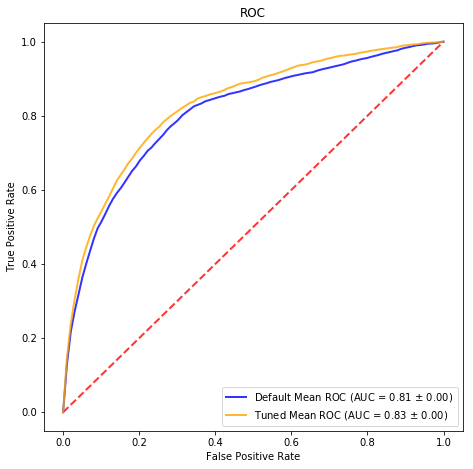

In [42]:
X, y = df.loc[:, (df.columns != 'Delinquent90')].to_numpy(),\
    df['Delinquent90'].to_numpy()

#Default classifier
classifier=LogisticRegression()
cv = StratifiedKFold(n_splits=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0


for train, test in cv.split(X, y):
    probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(y[test], probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    i += 1


mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)


plt.figure(figsize=(7.5,7.5))
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=.8)


plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Default Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

# GridSearchCV results
classifier=best_model.best_estimator_
cv = StratifiedKFold(n_splits=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


i = 0
for train, test in cv.split(X, y):
    probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(y[test], probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    

    i += 1

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='orange',
         label=r'Tuned Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

## Predicting labels in real_test

In [43]:
X_real_test = df_test.loc[:, df.columns!='Delinquent90']

In [44]:
X_real_pred = best_model.best_estimator_.predict(X_real_test)

In [45]:
df_exp = pd.concat([df_test['client_id'], pd.Series(X_real_pred)], axis=1)

In [46]:
df_exp.columns = ['client_id', 'Delinquent90']

In [47]:
df_exp.head()

,client_id,Delinquent90
0,60000,1
1,60001,0
2,60002,0
3,60003,0
4,60004,0


In [48]:
df_exp.to_csv('data/predicted.csv')